In [1]:
# Cell 1 — Import & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_PATH = r'D:\Jupyter\MLOps_Gold\\'
DATA_PATH = BASE_PATH + 'data\\'
VISUAL_PATH = BASE_PATH + 'visuals\\'

os.makedirs(VISUAL_PATH, exist_ok=True)

print("Setup selesai!")
print(f"Data path  : {DATA_PATH}")
print(f"Visual path: {VISUAL_PATH}")

Setup selesai!
Data path  : D:\Jupyter\MLOps_Gold\\data\
Visual path: D:\Jupyter\MLOps_Gold\\visuals\


In [2]:
# Cell 2 — Load Dataset
df = pd.read_csv(DATA_PATH + 'Dataset.csv', sep=';')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%Y.%m.%d %H:%M')
df = df.set_index('Date')
df = df.sort_index()

print(f"Data berhasil dimuat (raw)!")
print(f"Jumlah baris: {len(df):,}")
print(f"Kolom: {list(df.columns)}")
print(f"Periode: {df.index.min()} s/d {df.index.max()}")
df.head()

Data berhasil dimuat (raw)!
Jumlah baris: 6,789,606
Kolom: ['Open', 'High', 'Low', 'Close', 'Volume']
Periode: 2004-06-11 07:18:00 s/d 2026-01-30 23:59:00


,Open,High,Low,Close,Volume
Date,,,,,
2004-06-11 07:18:00,384.0,384.1,384.0,384.0,3
2004-06-11 07:23:00,384.1,384.1,384.0,384.0,2
2004-06-11 07:24:00,383.8,383.8,383.8,383.8,1
2004-06-11 07:25:00,383.8,384.3,383.8,384.3,3
2004-06-11 07:27:00,383.8,383.8,383.8,383.8,1


In [3]:
# Cell 3 — Statistik Deskriptif
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)
display(df.describe())

print(f"\nTipe Data:")
print(df.dtypes)

STATISTIK DESKRIPTIF


,Open,High,Low,Close,Volume
count,6.789606e+06,6.789606e+06,6.789606e+06,6.789606e+06,6.789606e+06
mean,1.497021e+03,1.497251e+03,1.496787e+03,1.497020e+03,7.191938e+01
std,6.502619e+02,6.504029e+02,6.501176e+02,6.502632e+02,1.305520e+02
min,3.811000e+02,3.811000e+02,3.811000e+02,3.811000e+02,1.000000e+00
25%,1.183413e+03,1.183560e+03,1.183260e+03,1.183413e+03,1.700000e+01
50%,1.328330e+03,1.328500e+03,1.328160e+03,1.328330e+03,4.400000e+01
75%,1.782030e+03,1.782290e+03,1.781770e+03,1.782030e+03,8.400000e+01
max,5.593610e+03,5.597600e+03,5.591010e+03,5.593630e+03,1.313800e+04



Tipe Data:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object


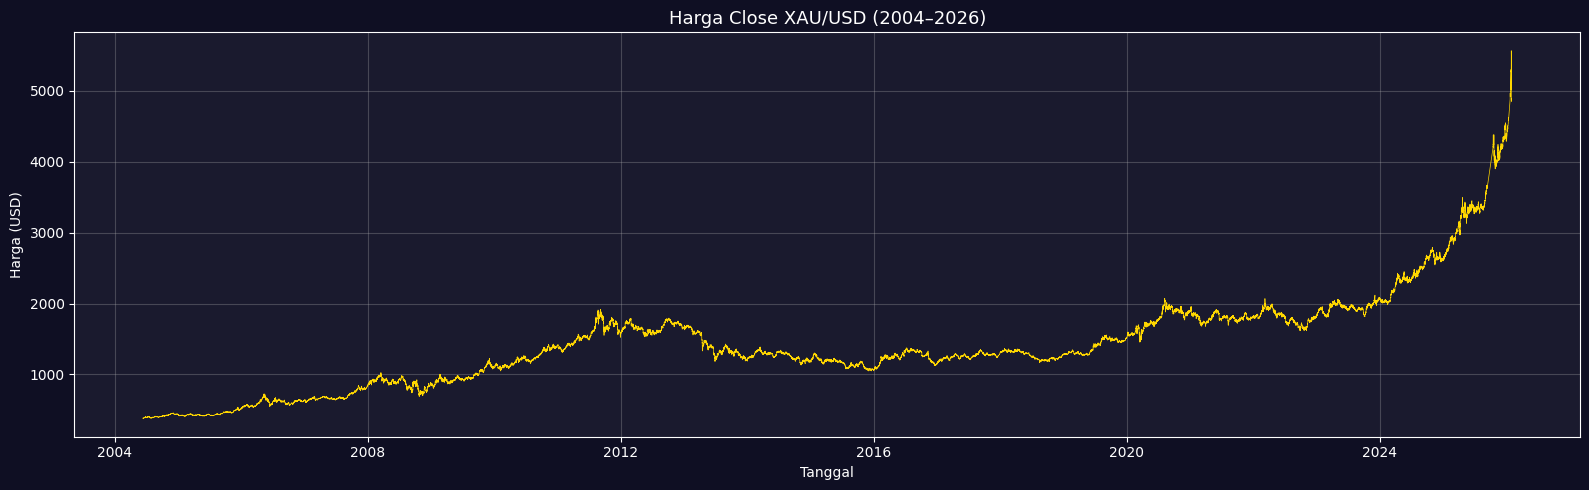

Visualisasi harga berhasil!


In [4]:
# Cell 4 — Visualisasi Harga Close
df_plot = df.resample('1h').last().dropna()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_plot.index, df_plot['Close'], color='gold', linewidth=0.5)
ax.set_title('Harga Close XAU/USD (2004–2026)', color='white', fontsize=13)
ax.set_ylabel('Harga (USD)', color='white')
ax.set_xlabel('Tanggal', color='white')
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.3)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'eda_harga.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi harga berhasil!")

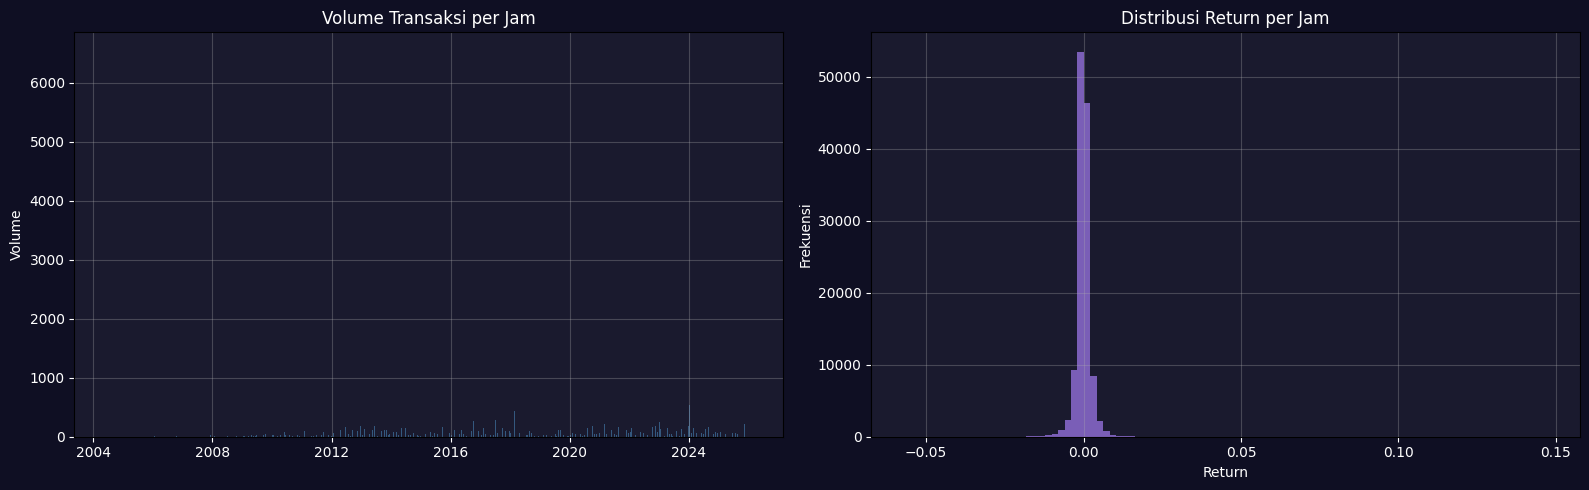

Visualisasi volume & return berhasil!


In [5]:
# Cell 5 — Visualisasi Volume & Distribusi Return
df_plot['Return'] = df_plot['Close'].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(df_plot.index, df_plot['Volume'], color='steelblue', width=0.02, alpha=0.6)
axes[0].set_title('Volume Transaksi per Jam', color='white')
axes[0].set_ylabel('Volume', color='white')
axes[0].set_facecolor('#1a1a2e')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(colors='white')

axes[1].hist(df_plot['Return'].dropna(), bins=100, color='mediumpurple', alpha=0.8)
axes[1].set_title('Distribusi Return per Jam', color='white')
axes[1].set_xlabel('Return', color='white')
axes[1].set_ylabel('Frekuensi', color='white')
axes[1].set_facecolor('#1a1a2e')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(colors='white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'eda_volume_return.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi volume & return berhasil!")

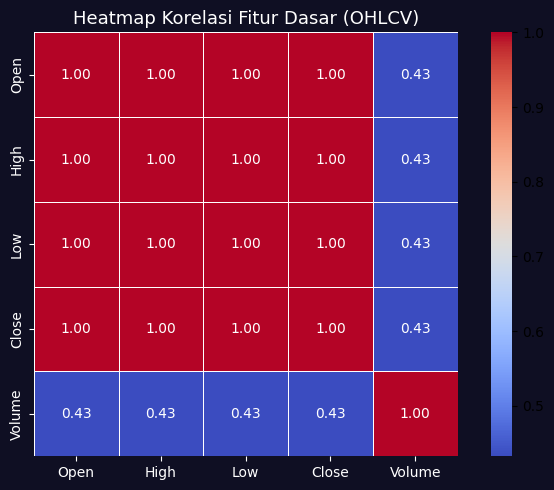

Heatmap korelasi berhasil!


In [6]:
# Cell 6 — Heatmap Korelasi OHLCV
df_corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Heatmap Korelasi Fitur Dasar (OHLCV)', color='white', fontsize=13)
fig.patch.set_facecolor('#0f0f23')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'eda_correlation_ohlcv.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap korelasi berhasil!")

In [7]:
# Cell 7 — Cek Anomali Data
print("=" * 50)
print("CEK ANOMALI DATA")
print("=" * 50)

print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nDuplikat (timestamp): {df.index.duplicated().sum():,} baris")
print(f"\nHarga Close <= 0: {(df['Close'] <= 0).sum():,} baris")

time_diff = df.index.to_series().diff().dropna()
gap = time_diff[time_diff > pd.Timedelta('1min')]
print(f"\nGap timestamp > 1 menit: {len(gap):,} kejadian")
print(f"   Gap terbesar: {gap.max()}")

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
outlier = df[(df['Close'] < Q1 - 3*IQR) | (df['Close'] > Q3 + 3*IQR)]
print(f"\nOutlier harga Close (3x IQR): {len(outlier):,} baris")

invalid = df[df['High'] < df['Low']]
print(f"\nHigh < Low: {len(invalid):,} baris")

print("\n" + "=" * 50)
print("Pengecekan anomali selesai!")
print("=" * 50)

CEK ANOMALI DATA

Missing Values:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplikat (timestamp): 0 baris

Harga Close <= 0: 0 baris

Gap timestamp > 1 menit: 214,113 kejadian
   Gap terbesar: 32 days 08:12:00

Outlier harga Close (3x IQR): 101,401 baris

High < Low: 0 baris

Pengecekan anomali selesai!


C:\Users\acer\AppData\Local\Temp\ipykernel_27368\2775407083.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_27368\2775407083.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(VISUAL_PATH + 'eda_outlier.png', dpi=150, bbox_inches='tight')
D:\Jupyter\env_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


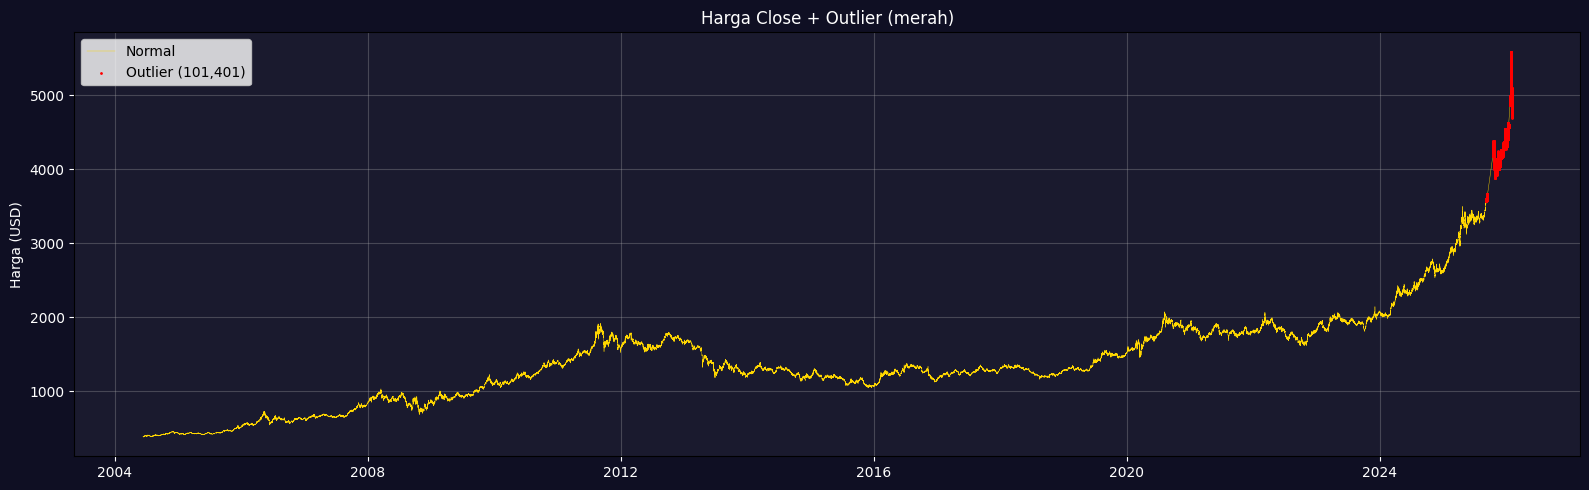

Visualisasi outlier berhasil!


In [8]:
# Cell 8 — Visualisasi Outlier
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df['Close'], color='gold', linewidth=0.3, label='Normal')

outlier_mask = (df['Close'] < Q1 - 3*IQR) | (df['Close'] > Q3 + 3*IQR)
ax.scatter(df.index[outlier_mask], df['Close'][outlier_mask],
           color='red', s=1, label=f'Outlier ({outlier_mask.sum():,})', zorder=5)

ax.set_title('Harga Close + Outlier (merah)', color='white')
ax.set_ylabel('Harga (USD)', color='white')
ax.legend()
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.3)
ax.tick_params(colors='white')

fig.patch.set_facecolor('#0f0f23')
plt.tight_layout()
plt.savefig(VISUAL_PATH + 'eda_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi outlier berhasil!")

In [9]:
# Cell 9 — Summary EDA
print("=" * 50)
print("RINGKASAN EDA")
print("=" * 50)
print(f"\nTotal baris: {len(df):,}")
print(f"Periode: {df.index.min()} s/d {df.index.max()}")
print(f"Harga Close min: ${df['Close'].min():.2f}")
print(f"Harga Close max: ${df['Close'].max():.2f}")
print(f"\nTemuan yang perlu ditindaklanjuti di Preprocessing:")
print(f"   - Duplikat timestamp: {df.index.duplicated().sum():,} baris")
print(f"   - Gap timestamp     : {len(gap):,} kejadian")
print(f"   - Outlier (3x IQR) : {len(outlier):,} baris")
print("\nData siap untuk Preprocessing!")
print("=" * 50)

RINGKASAN EDA

Total baris: 6,789,606
Periode: 2004-06-11 07:18:00 s/d 2026-01-30 23:59:00
Harga Close min: $381.10
Harga Close max: $5593.63

Temuan yang perlu ditindaklanjuti di Preprocessing:
   - Duplikat timestamp: 0 baris
   - Gap timestamp     : 214,113 kejadian
   - Outlier (3x IQR) : 101,401 baris

Data siap untuk Preprocessing!
